<a href="https://colab.research.google.com/github/chayansaha2/Project-/blob/main/IPL_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving IPL.csv to IPL.csv


In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("IPL.csv")
df.head()

#Basic information
df.info()
#check the size of the dataset
print(f"Number of row present {df.shape[0]} and number of column {df.shape[1]}")

#Total null values
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


Now, Here comes some Basic Questions

Which team won the most matches?

Text(0, 0.5, 'Teams')

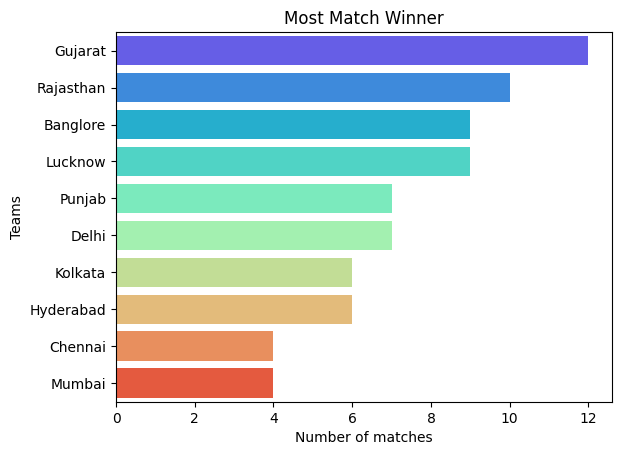

In [16]:
match_winner = df['match_winner'].value_counts()
sns.barplot(x=match_winner.values , y = match_winner.index,palette='rainbow')
plt.title("Most Match Winner")
plt.xlabel("Number of matches")
plt.ylabel("Teams")

Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Trends ')

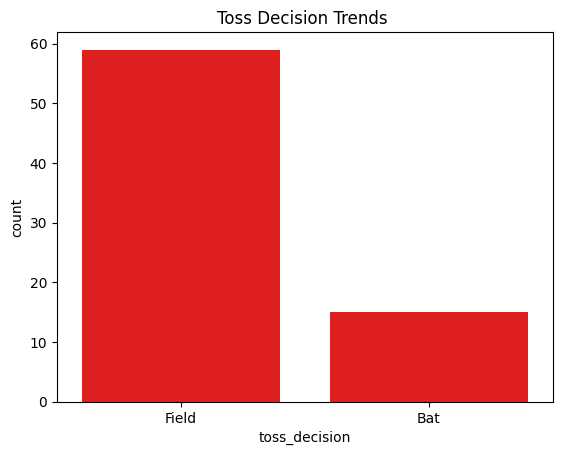

In [20]:
sns.countplot(x = df['toss_decision'],color="red")
plt.title("Toss Decision Trends ")


Toss Winner vs Match Winner

In [21]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count *100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

How do teams win? (Runs vs Wickets)

Text(0.5, 1.0, 'Won by')

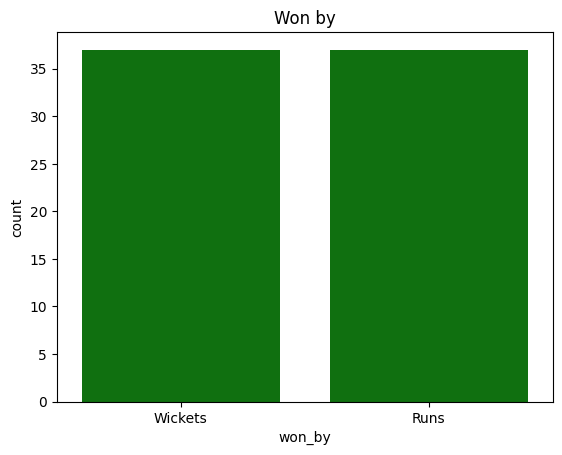

In [22]:
sns.countplot(x = df['won_by'],color ="green")
plt.title("Won by")

Key Player Performances
1 Most "Player of the Match" Awards

Text(0.5, 1.0, 'Top 10 plauers with man of the match')

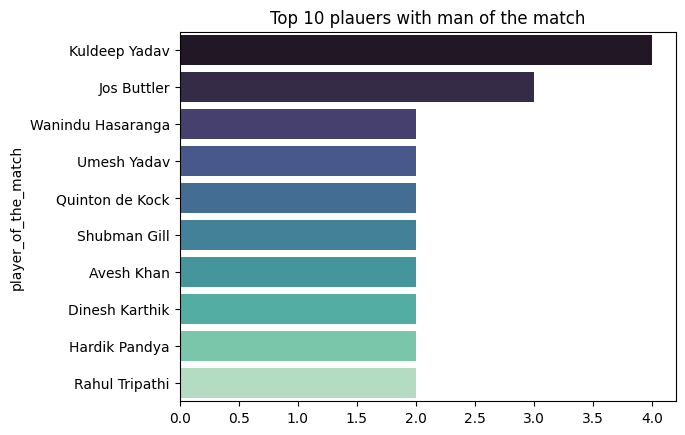

In [23]:
count = df['player_of_the_match'].value_counts().head(10)
sns.barplot(x = count.values , y = count.index,palette='mako')
plt.title("Top 10 plauers with man of the match")

2 Top Scorers

<Axes: ylabel='top_scorer'>

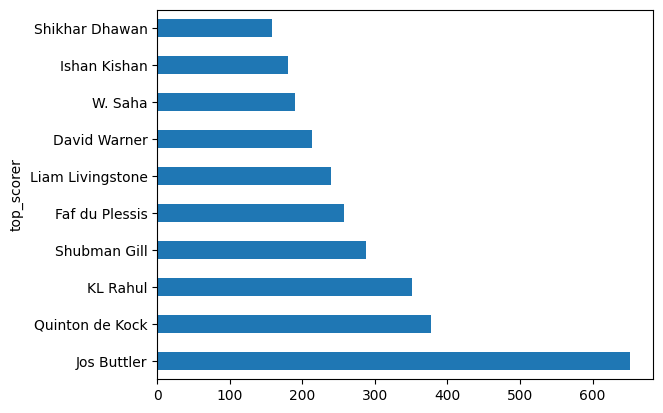

In [24]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(10)
high
high.plot(kind = 'barh')

10 Best Bowling Figures

<Axes: ylabel='best_bowling'>

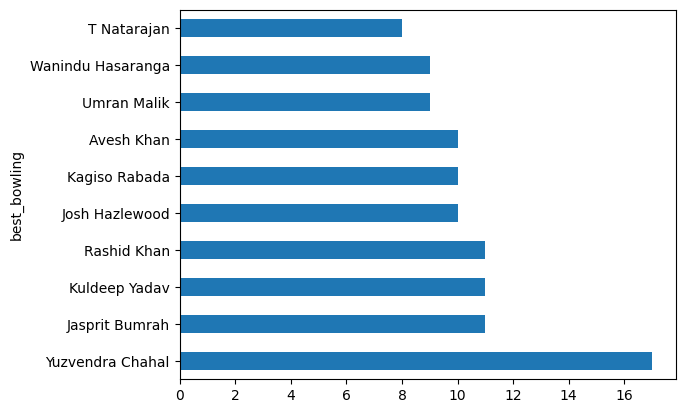

In [25]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind = 'barh')

Venue Analysis
Most Matches Played by Venue

<Axes: ylabel='venue'>

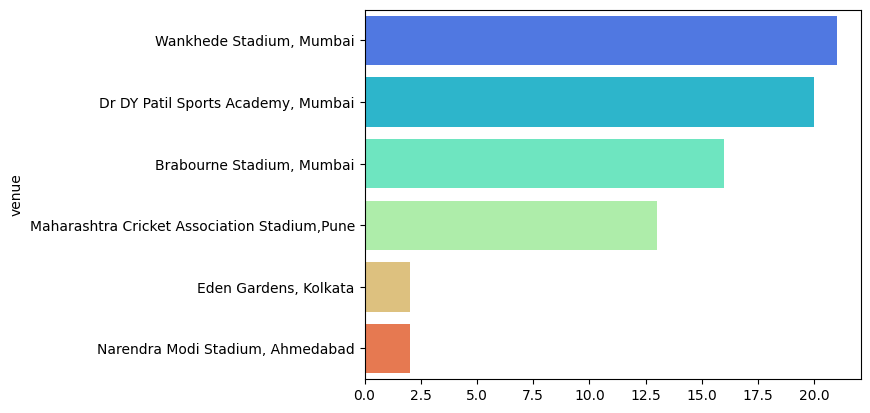

In [26]:
venue_count = df['venue'].value_counts()
venue_count
sns.barplot(y = venue_count.index,x = venue_count.values,palette='rainbow')

Custom Questions & Insights
Q1: Who won the highest margin by runs?

In [27]:
df[df['won_by'] == 'Runs'].sort_values(by = 'margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


Q2: Which player had the highest individual score?

In [28]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Q3: Which bowler had the best bowling figures?

In [29]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
